# Importing the necessary libraries

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#Loading dataset
df = pd.read_csv('mail_data.csv')

(5572, 2)

In [3]:
# Display basic information
display(df.head())
display(df.info())

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None

# Trying to understand the dataset

In [4]:
# Trying to find nulls/ missing values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [5]:
# Spam – Unwanted, unsolicited, or junk emails, often promotional or fraudulent.
# Ham – Legitimate, non-spam emails that are useful and relevant.
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

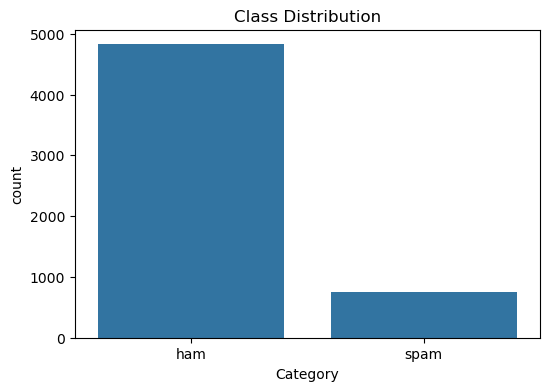

In [7]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))
sns.countplot(x='Category', data=df)
plt.title("Class Distribution")
plt.show()

Data seems to be imbalanced since spam records are more than the ham records which will affect the predection. Imbalance in data refers specifically to the distribution of different classes in a classification problem, it is called class imbalance.

# Preprocessing

Lets normalise the text by converting it to lowercase and removing non-alphanumeric characters.

In [17]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df['Message'] = df['Message'].astype(str).apply(preprocess_text)


Split the data to make sure the model isn’t just memorizing the data and can instead generalize to new situations. It helps in evaluating how well the model will perform in the real world.

In [16]:
# Splitting data
X = df['Message']
y = df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Using vectorization to transform raw data into a numerical format that can be used by machine learning algorithms, allowing the model to understand, learn from, and make predictions based on that data.

In [18]:
# Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Handling class imbalance is crucial to ensure that machine learning models don't ignore minority classes, leading to better performance, especially in situations where both classes are important.

In [ ]:
# Handling class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

<7718x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 95203 stored elements in Compressed Sparse Row format>

In [20]:
# Model Training
model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

In [21]:
# Predictions
y_pred = model.predict(X_test_vec)

In [22]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.979372197309417
Classification Report:
               precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.94      0.90      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[958   8]
 [ 15 134]]


In [28]:
# Model Training with MultinomialNB
model_nb = MultinomialNB()
model_nb.fit(X_train_resampled, y_train_resampled)

MultinomialNB()

In [29]:
# Predictions
y_pred_nb = model_nb.predict(X_test_vec)

In [30]:
# Evaluation
print("Accuracy (MultinomialNB):", accuracy_score(y_test, y_pred_nb))
print("Classification Report (MultinomialNB):\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix (MultinomialNB):\n", confusion_matrix(y_test, y_pred_nb))

Accuracy (MultinomialNB): 0.9605381165919282
Classification Report (MultinomialNB):
               precision    recall  f1-score   support

         ham       0.99      0.97      0.98       966
        spam       0.81      0.93      0.86       149

    accuracy                           0.96      1115
   macro avg       0.90      0.95      0.92      1115
weighted avg       0.96      0.96      0.96      1115

Confusion Matrix (MultinomialNB):
 [[933  33]
 [ 11 138]]
